## Demonstration - Monitoring Model Quality

In this demonstration, we will investigate how Databricks enables drift detection using various tools and features such as Notebooks, Queries, Dashboards, Alerts, while emphasizing Lakehouse Monitoring. Lakehouse Monitroing is leveraged to monitor the quality and statistical properties of data and ML models within the Databricks Lakehouse architecture. It allows you to track data quality, detect anomalies, and monitor the performance of ML models and model-serving endpoints.

As a part of the classroom setup, we will bring in a pre-generated inference table (with Change Data Feed enabled) utilizing Databricks' Marketplace as well as a baseline dataset to help demonstrate how we can detect and investigate drift. In practice, it is recommended that Delta Lake's Change Data Feed (CDF), which allows Databricks to track row-level changes between versions of a Delta table, be enabled on inference tables by default. By leveraging CDF, data scientists can more efficiently create and monitor inference tables.

### Learning Objectives

By the end of this demonstration, you will be able to do the following:

* Understand how to apply Lakehouse Monitoring for detecting different types of drift. Here are the core concepts and features:
  * Automated Dashboards built to analyze an inference profile
  * Know various ways in which you can locate the dashboard (Workspace, and Lineage and Quality in Catalog Explorer)
  * Know various ways in which you can create additional widgets in the dashboard
  * Automate profile and drift metric tables
  * Out-of-the-box metrics and custom metrics
  * Inspect inference profile lineage and create alerts for sending notifications when metrics change
  * Using Lakehouse Monitoring to build custom for analyzing possible drift.
    * Review of various types of drift and Lakehouse Monitoring can be applied
* Understand additional configurations and features using the UI
  * How to Update a baseline feature table
  * Update slicing configurations

**Note: This demonstration uses a mixture of SQL and Python.**

---

## Requirements

Please review the following requirements before starting the lesson:

* To run this notebook, you need to use one of the following Databricks runtime(s): **15.4.x-cpu-ml-scala2.12**
* To utilize the generated Dashboard, you will need a SQL Warehouse.

---

## REQUIRED - SELECT CLASSIC COMPUTE

Before executing cells in this notebook, please select your classic compute cluster in the lab. Be aware that **Serverless** is enabled by default. Follow these steps to select the classic compute cluster:

1. Navigate to the top-right of this notebook and click the drop-down menu to select your cluster. By default, the notebook will use **Serverless**.
2. If your cluster is available, select it and continue to the next cell. If the cluster is not shown:
   * In the drop-down, select **More**.
   * In the **Attach to an existing compute resource** pop-up, select the first drop-down. You will see a unique cluster name in that drop-down. Please select that cluster.

**NOTE:** If your cluster has terminated, you might need to restart it in order to select it. To do this:

1. Right-click on **Compute** in the left navigation pane and select *Open in new tab*.
2. Find the triangle icon to the right of your compute cluster name and click it.
3. Wait a few minutes for the cluster to start.
4. Once the cluster is running, complete the steps above to select your cluster.

## Classroom Setup

To get into the lesson, we first need to build some data assets and define some configuration variables required for this demonstration. When running the following cell, the output is hidden so our space isn't cluttered. To view the details of the output, you can hover over the next cell and click the eye icon.

The cell after the setup, titled `View Setup Variables`, displays the various variables that were created. You can click the Catalog icon in the notebook space to the right to see that your catalog was created with no data.

In [0]:
#%run ../Includes/Classroom-Setup-Demo-M03

In [0]:
#print(f"Username:         {DA.username}")
#print(f"Catalog Name:     {DA.catalog_name}")
#print(f"Schema Name:      {DA.schema_name}")
#print(f"Working Directory: {DA.paths.working_dir}")
#print(f"Dataset Location: {DA.paths.datasets}")

In [0]:
#Username:         labuser8560440_1733456225@vocareum.com
#Catalog Name:     dbacademy
#Schema Name:      rich_pegboard
#Working Directory: /Volumes/dbacademy/ops/labuser8560440_1733456225@vocareum_com
#Dataset Location: NestedNamespace(cdc_diabetes='/Volumes/dbacademy_cdc_diabetes/v01', diabetes_inference='/Volumes/dbacademy_diabetes_inference/v01')

## Inference and Feature Tables

As a part of the classroom setup, we have created two tables:

1. `model_logs`: This is our inference table. It contains inference data from a sequence of queries that were made prior to this demo and will act as our dataset that is drifting away from the baseline data (you can access the dataset yourself in the Marketplace here).
2. `baseline_features`: This is our baseline table and acts as our source of truth.

---

### A Remark on Inference Tables and Inference Profiles

It's important to distinguish between an inference table when thinking about the assets we will be working with. An inference table can be thought of as a collection of logs from the model that contain the input features at runtime and predicted labels. You can also include the true labels if they are available. On the other hand, an inference profile is an inference table that also contains profile metrics like F1-score, accuracy, or other evaluation metrics that measure the performance of the model on the inferred data.

In [0]:
primary_table_name = 'model_logs'
baseline_table_name = 'baseline_features'

primary_df = spark.read.format('delta').table(primary_table_name)
primary_pdf = primary_df.toPandas()

baseline_df = spark.read.format('delta').table(baseline_table_name)
baseline_pdf = baseline_df.toPandas()

In [0]:
primary_pdf.tail(5) #model_logs'

,status_code,timestamp,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Diabetes_binary,model_id,labeled_data
9,200,2026-08-09 23:53:03,0.0,12.0,1,0,2.0,32.50,6.5,140,1,0,0
10,200,2026-07-13 01:17:16,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
11,200,2026-08-12 01:17:16,0.0,12.0,1,0,2.0,32.50,6.5,140,1,0,0
12,200,2026-07-16 17:55:54,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
13,200,2026-08-15 17:55:54,0.0,12.0,1,0,2.0,32.50,6.5,140,1,0,0


In [0]:
baseline_pdf.tail() #'baseline_features'

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Diabetes_binary,id,model_id,labeled_data
9757,0.0,1.48,0,0,0.0,27.32,4.5,140,0,99916,0,0
9758,0.0,7.00,0,0,0.0,19.77,6.5,100,0,99932,0,0
9759,0.0,5.00,0,0,0.0,13.34,6.5,155,0,99933,0,0
9760,1.0,2.00,0,0,0.0,16.86,6.1,145,0,99940,0,0
9761,0.0,2.00,0,0,0.0,17.37,6.5,100,0,99996,0,0


In [0]:
# 9
#workspace.default.batch_inference
#model_inference_table?
inference_df = spark.read.format('delta').table('model_inference_table')

display(baseline_df.tail(20))
display(primary_df)

gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Diabetes_binary,id,model_id,labeled_data
0.0,0.32,0,0,0.0,12.26,5.8,126,0,99778,0,0
0.0,7.0,0,0,0.0,27.32,3.5,126,0,99780,0,0
1.0,5.0,0,0,0.0,27.32,6.1,145,0,99798,0,0
0.0,3.0,0,0,4.0,27.32,3.5,90,0,99808,0,0
1.0,5.0,0,0,0.0,16.19,5.7,140,0,99812,0,0
1.0,8.0,0,0,5.0,17.43,4.8,130,0,99813,0,0
1.0,7.0,0,0,0.0,14.66,5.8,158,0,99825,0,0
1.0,3.0,0,0,0.0,27.32,5.0,85,0,99836,0,0
0.0,9.0,0,0,0.0,14.13,6.5,200,0,99841,0,0
0.0,4.0,0,0,0.0,16.88,5.8,159,0,99847,0,0


status_code,timestamp,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Diabetes_binary,model_id,labeled_data
200,2026-07-10T02:57:43.000Z,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
200,2026-08-09T02:57:43.000Z,0.0,12.0,1,0,2.0,32.5,6.5,140,1,0,0
200,2026-07-10T14:25:54.000Z,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
200,2026-08-09T14:25:54.000Z,0.0,12.0,1,0,2.0,32.5,6.5,140,1,0,0
200,2026-07-10T20:23:32.000Z,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
200,2026-08-09T20:23:32.000Z,0.0,12.0,1,0,2.0,32.5,6.5,140,1,0,0
200,2026-07-10T23:10:33.000Z,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
200,2026-08-09T23:10:33.000Z,0.0,12.0,1,0,2.0,32.5,6.5,140,1,0,0
200,2026-07-10T23:53:03.000Z,1.0,10.0,0,0,0.0,27.32,4.0,80,0,0,0
200,2026-08-09T23:53:03.000Z,0.0,12.0,1,0,2.0,32.5,6.5,140,1,0,0


In [0]:
inference_df = spark.read.format('delta').table('batch_inference')
inference_df.show(5)


+----------+-----+-------------+------+--------------+------------+----------+
|customerID|Churn|SeniorCitizen|tenure|MonthlyCharges|TotalCharges|prediction|
+----------+-----+-------------+------+--------------+------------+----------+
|0151-ONTOV| NULL|          0.0|   1.0|          70.9|        70.9|       Yes|
|0238-WHBIQ| NULL|          0.0|  72.0|          89.7|      6339.3|        No|
|0369-ZGOVK| NULL|          0.0|  28.0|          70.4|      1992.2|        No|
|0407-BDJKB| NULL|          0.0|  60.0|         95.75|      5742.9|        No|
|0455-XFASS| NULL|          0.0|   3.0|         69.55|       200.2|       Yes|
+----------+-----+-------------+------+--------------+------------+----------+
only showing top 5 rows


## Motivating Drift Investigation

We'll take a cross-sectional snapshot of the distributions of BMI and Diabete_binary data to compare the the ground truth to the the data in our inference table.

In [0]:
# 11: BMI Distribution Snapshot

# Compare distributions for a feature
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

#Randomly sample from the pandas dataframe baseline_pdf with samples equal to the size of primary_pdf
baseline_pdf_sample = baseline_pdf.sample(n=len(primary_pdf), random_state=1)



In [0]:
baseline_pdf_sample.sample(2)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Diabetes_binary,id,model_id,labeled_data
1338,1.0,4.0,0,0,0.0,18.99,4.5,80,0,13524,0,0
8463,0.0,5.0,0,0,0.0,16.36,6.5,145,0,86581,0,0


In [0]:

# KS test
#stat, p_value = stats.ks_2samp(baseline_pdf_sample['BMI'], primary_pdf['BMI'])
stat, p_value = stats.ks_2samp(baseline_pdf_sample['bmi'], primary_pdf['bmi'])


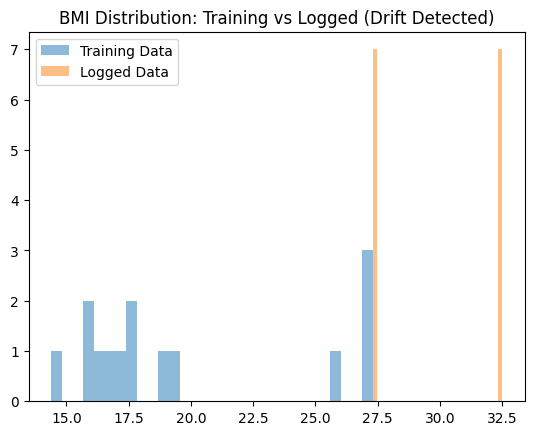

In [0]:
# Visualization 1
plt.hist(baseline_pdf_sample['bmi'], bins=30, alpha=0.5, label="Training Data")
plt.hist(primary_pdf['bmi'], bins=30, alpha=0.5, label="Logged Data")
plt.legend()
plt.title("BMI Distribution: Training vs Logged (Drift Detected)")
plt.show()

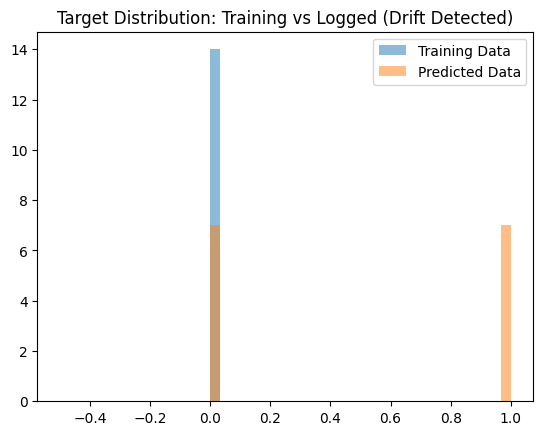

KS Test statistic value: 0.7857142857142857 and p-value: 0.0001633239108000179


In [0]:



# Visualization 2
plt.hist(baseline_pdf_sample['labeled_data'], bins=30, alpha=0.5, label="Training Data")
plt.hist(primary_pdf['Diabetes_binary'], bins=30, alpha=0.5, label="Predicted Data")
plt.legend()
plt.title("Target Distribution: Training vs Logged (Drift Detected)")
plt.show()

print(f'KS Test statistic value: {stat} and p-value: {p_value}')

In [0]:
print("Esses dois gráficos comparam a distribuição dos dados de treino (baseline) com os dados que o modelo está recebendo e prevendo em produção (logs de inferência). O objetivo é identificar visualmente se houve desvio significativo (drift) nos dados ao longo do tempo.")

Esses dois gráficos comparam a distribuição dos dados de treino (baseline) com os dados que o modelo está recebendo e prevendo em produção (logs de inferência). O objetivo é identificar visualmente se houve desvio significativo (drift) nos dados ao longo do tempo.


2. Explicação do Gráfico 1: BMI Distribution: Training vs Logged (Drift Detected)
O que representa: Comparação da funcionalidade/feature de entrada (IMC / BMI).

Análise das Histogramas:

Training Data (Azul): Mostra o perfil de IMC dos pacientes no momento em que o modelo foi treinado.

Logged Data (Laranja): Mostra o perfil de IMC das requisições que estão chegando ao modelo atualmente no ambiente de produção.

Conclusão de Negócio/ML: Houve um Data Drift (ou Feature Drift). A população que está usando o sistema agora tem uma distribuição de IMC diferente da população original de treino (por exemplo, os picos e dispersões não se sobrepõem perfeitamente).

3. Explicação do Gráfico 2: Target Distribution: Training vs Logged (Drift Detected)
O que representa: Comparação da variável alvo / resposta (Diabetes_binary).

Análise das Histogramas:

Training Data (Azul): A proporção real de classes (com e sem diabetes) no conjunto de treino (labeled_data).

Predicted Data (Laranja): A proporção de saídas/previsões que o modelo está gerando em produção (Diabetes_binary).

Conclusão de Negócio/ML: Houve um Prediction Drift (ou Output Drift). O modelo está classificando muito mais (ou muito menos) casos positivos/negativos em produção em comparação com a proporção histórica esperada.

"Abaixo dos gráficos, utilizamos o Teste Kolmogorov-Smirnov (KS Test) para quantificar matematicamente essa diferença. Como o p-valor resultante é extremamente baixo (p<0.05), confirmamos estatisticamente que as distribuições mudaram significativamente. Isso indica que o modelo pode estar degradando e precisa ser reavaliado ou retreinado com dados mais recentes."

## Lakehouse Monitoring

To monitor the performance of the model we used to build our premade `model_logs` table, we will attach the monitor to this table. Our baseline table `baseline_features` is what we can consider as our *good* or *source of truth* data. The Databricks monitor creates out-of-the-box metrics that are important and sets up two tables:

1. **Profile metrics table:** This keeps track of profile metrics, which is a summary statistic computed for each column.
2. **Drift metrics table:** This keeps track of changes in profile metrics compared to baseline or previous time window.

These two tables are used to automatically generate a monitoring dashboard. Later, we will uses these tables to build an alert for drift.

---

## Option 1: Using the UI

Let's first start with recalling how we can use the UI to setup with Lakehouse Monitoring

To add a monitor on the inference table,

1. Open the **Catalog** menu from the left menu bar.
2. Select the table **diabetes_model_logs** within your catalog and schema.
3. Click on the **Quality** tab then on the **Get started** button.
4. As **Profile type** select **Inference profile**.
5. As **Problem type** select **classification**.
6. As the **Prediction column** select **Diabetes_binary**.
7. As the **Label column** select **labeled_data**.
8. As **Metric granularities** select **5 minutes**, **1 hour**, and **1 day**. We will use the doctored timestamps to simulate requests that have been received over a large period of time.
9. As **Timestamp column** select **timestamp**.
10. As **Model ID column** select **model_id**.
11. In Advanced Options --> **Unity catalog baseline table name (optional)** enter **Your baseline table name** from above
12. Click the **Create** button.

---

## Option 2: Pythonic Approach

For a more programmatic approach, you can run the following code to initiate Lakehouse Monitoring. This method allows you to automate and customize the monitoring according to specific needs and thresholds.

In [0]:
# 15
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.catalog import MonitorInferenceLog, MonitorInferenceLogProblemType, MonitorInfoStatus, MonitorRefreshInfoState, MonitorMetric
w = WorkspaceClient()
#full_primary_table_name = f'{DA.catalog_name}.{DA.schema_name}.{primary_table_name}'
#full_baseline_table_name = f"{DA.catalog_name}.{DA.schema_name}.baseline_features"
catalog_name = 'workspace'
schema_name ='default'
full_primary_table_name = f'{catalog_name}.{schema_name}.{primary_table_name}_2'
#full_baseline_table_name = f"{catalog_name}.{schema_name}.baseline_features_2"

#full_primary_table_name = f'{catalog_name}.{schema_name}.{primary_table_name}'
full_baseline_table_name = f"{catalog_name}.{schema_name}.baseline_features"

In [0]:
#spark.sql("""
#          CREATE OR REPLACE TABLE workspace.default.baseline_features_29082026 AS 
#          SELECT * 
#          FROM workspace.default.baseline_features
#          
#          """)


#spark.sql("""
#          CREATE OR REPLACE TABLE workspace.default.model_logs AS 
#          SELECT * 
#          FROM workspace.default.model_logs_29082026
#          
 #         """)


In [0]:
#spark.sql("""
#          CREATE OR REPLACE TABLE workspace.default.model_logs_29082026 AS 
#          SELECT * 
#          FROM workspace.default.model_logs
#          
#          """)

In [0]:
help(w.quality_monitors.create)

Help on method create in module databricks.sdk.service.catalog:

create(table_name: 'str', output_schema_name: 'str', assets_dir: 'str', *, baseline_table_name: 'Optional[str]' = None, custom_metrics: 'Optional[List[MonitorMetric]]' = None, data_classification_config: 'Optional[MonitorDataClassificationConfig]' = None, inference_log: 'Optional[MonitorInferenceLog]' = None, latest_monitor_failure_msg: 'Optional[str]' = None, notifications: 'Optional[MonitorNotifications]' = None, schedule: 'Optional[MonitorCronSchedule]' = None, skip_builtin_dashboard: 'Optional[bool]' = None, slicing_exprs: 'Optional[List[str]]' = None, snapshot: 'Optional[MonitorSnapshot]' = None, time_series: 'Optional[MonitorTimeSeries]' = None, warehouse_id: 'Optional[str]' = None) -> 'MonitorInfo' method of databricks.sdk.service.catalog.QualityMonitorsAPI instance
    Creates a new monitor for the specified table.

    The caller must either: 1. be an owner of the table's parent catalog, have **USE_SCHEMA** on th

In [0]:
username ='fabieneaulas@gmail.com'

In [0]:
# 17

# ML problem type, either "classification" or "regression"
PROBLEM_TYPE = MonitorInferenceLogProblemType.PROBLEM_TYPE_CLASSIFICATION

# Window sizes to analyze data over
GRANULARITIES = ["1 day"]

# Directory to store generated dashboard
ASSETS_DIR = f"/Workspace/Users/{username}/databricks_lakehouse_monitoring/{primary_table_name}"

# Optional parameters
SLICING_EXPRS = ["Age < 2", "Age > 15", "Sex = 1", "HighChol = 1"]  # Expressions to slice data with

In [0]:
#spark.sql("""
#          CREATE OR REPLACE TABLE workspace.default.model_logs_2 AS 
#          SELECT * 
#          FROM workspace.default.model_logs_29082026
#          
#        """)


In [0]:
# 18

print(f"Creating monitor for model_logs")

# Delete existing monitor if it exists
try:
    w.quality_monitors.delete(table_name=full_primary_table_name)
    print(f"Deleted existing monitor for {full_primary_table_name}")
    import time
    time.sleep(5)  # Wait for deletion to complete
except Exception as e:
    print(f"No existing monitor to delete: {e}")

try:
    info = w.quality_monitors.create(
        table_name=full_primary_table_name,
        inference_log=MonitorInferenceLog(
            timestamp_col='timestamp',
            granularities=GRANULARITIES,
            model_id_col='model_id',  # Model version number
            prediction_col='Diabetes_binary',  # Ensure this column is of type DOUBLE
            problem_type=PROBLEM_TYPE,
            label_col='labeled_data'  # Ensure this column is of type DOUBLE
        ),
        baseline_table_name=full_baseline_table_name,
        slicing_exprs=SLICING_EXPRS,
        output_schema_name=f"{catalog_name}.{schema_name}",
        assets_dir=ASSETS_DIR
    )

    import time

    # Wait for monitor to be created
    while info.status == MonitorInfoStatus.MONITOR_STATUS_PENDING:
        info = w.quality_monitors.get(table_name=full_primary_table_name)
        time.sleep(10)

    assert info.status == MonitorInfoStatus.MONITOR_STATUS_ACTIVE, "Error creating monitor"
except Exception as e:
    print(f"Error creating monitor: {e}")

Creating monitor for model_logs
No existing monitor to delete: Cannot find Monitor with ID: /metastores:614990e9-f604-4bdb-9502-70930c608b4a/tables:118a8594-d897-44e4-9d74-eed2f81e4950/


In [0]:
# 19

# A metric refresh will automatically be triggered on creation
refreshes = w.quality_monitors.list_refreshes(table_name=full_primary_table_name).refreshes
assert(len(refreshes) > 0)

run_info = refreshes[0]
while run_info.state in (MonitorRefreshInfoState.PENDING, MonitorRefreshInfoState.RUNNING):
    run_info = w.quality_monitors.get_refresh(table_name=full_primary_table_name, refresh_id=run_info.refresh_id)
    print(run_info)
    time.sleep(30)

assert run_info.state == MonitorRefreshInfoState.SUCCESS, "Monitor refresh failed"

MonitorRefreshInfo(refresh_id=641906867715412, state=<MonitorRefreshInfoState.RUNNING: 'RUNNING'>, start_time_ms=1788049472905, end_time_ms=None, message=None, trigger=<MonitorRefreshInfoTrigger.MANUAL: 'MANUAL'>)
MonitorRefreshInfo(refresh_id=641906867715412, state=<MonitorRefreshInfoState.RUNNING: 'RUNNING'>, start_time_ms=1788049472905, end_time_ms=None, message=None, trigger=<MonitorRefreshInfoTrigger.MANUAL: 'MANUAL'>)
MonitorRefreshInfo(refresh_id=641906867715412, state=<MonitorRefreshInfoState.RUNNING: 'RUNNING'>, start_time_ms=1788049472905, end_time_ms=None, message=None, trigger=<MonitorRefreshInfoTrigger.MANUAL: 'MANUAL'>)
MonitorRefreshInfo(refresh_id=641906867715412, state=<MonitorRefreshInfoState.RUNNING: 'RUNNING'>, start_time_ms=1788049472905, end_time_ms=None, message=None, trigger=<MonitorRefreshInfoTrigger.MANUAL: 'MANUAL'>)
MonitorRefreshInfo(refresh_id=641906867715412, state=<MonitorRefreshInfoState.RUNNING: 'RUNNING'>, start_time_ms=1788049472905, end_time_ms=None

---------------------------------------------------------------------------
AssertionError                            Traceback (most recent call last)
File <command-7147754553100167>, line 13
     10     print(run_info)
     11     time.sleep(30)
---> 13 assert run_info.state == MonitorRefreshInfoState.SUCCESS, "Monitor refresh failed"

AssertionError: Monitor refresh failed

In [0]:
# o dashboard

# usar model_logs_2

In [0]:
w.quality_monitors.get(table_name=full_primary_table_name)

MonitorInfo(output_schema_name='workspace.default', table_name='workspace.default.model_logs_2', status=<MonitorInfoStatus.MONITOR_STATUS_ACTIVE: 'MONITOR_STATUS_ACTIVE'>, profile_metrics_table_name='workspace.default.model_logs_2_profile_metrics', drift_metrics_table_name='workspace.default.model_logs_2_drift_metrics', monitor_version=0, assets_dir='/Workspace/Users/fabieneaulas@gmail.com/databricks_lakehouse_monitoring/model_logs', baseline_table_name='workspace.default.baseline_features', custom_metrics=[], dashboard_id='01f1a4092bbd132eb5f6adce36c74b19', data_classification_config=None, inference_log=MonitorInferenceLog(problem_type=<MonitorInferenceLogProblemType.PROBLEM_TYPE_CLASSIFICATION: 'PROBLEM_TYPE_CLASSIFICATION'>, timestamp_col='timestamp', granularities=['1 day'], prediction_col='Diabetes_binary', model_id_col='model_id', label_col='labeled_data', prediction_proba_col=None), latest_monitor_failure_msg=None, notifications=None, schedule=None, slicing_exprs=['Age < 2', 'Ag

## Explore the Lakehouse Monitoring Dashboard

Methods for accessing the dashboard:

1. Run the next cell and click on the generated link. This will take you to the Dashboard that was automatically created.
2. Navigate to `model_logs` in the Catalog Explorer and select Quality and click on View Dashboard.
3. The Dashboard (and other assets) are automatically registered to the lineage of `model_logs` as a part of comprehensive and automated tracking with Unity Catalog.
4. Setting the `ASSETS_DIR` gives the location for where the generated dashboards are actually stored. In this demo, this is set to `f"/Workspace/Users/{DA.username}/databricks_lakehouse_monitoring/{primary_table_name}"`.

The dashboard provides a comprehensive view of the data quality and statistical properties of the tables being monitored. It helps in tracking data integrity, statistical distribution, and data drift over time. This is where you will prebuilt widgets that incorporate the metrics generated from the profile and drift metric tables. The dashboard should be thought of as a starting point for monitoring for drift, hence it is fully customizable.

* At the top left you can toggle between viewing the **Canvas** or the underlying **Data** that was generated with dashboard using SQL logic. Note that if a widget is currently being used, then the dataset created cannot be deleted.
* Select widget that reads **# Inferences** on the left side of the canvas
  * Click on the kabob and select **View Dataset**. This will take you to the generated SQL code that you can use for further analysis with the SQL Editor or in this notebook.
  * Try editing the code and clicking **Run** to see how you can analyze the underlying tables generated as a part of the Dashboard creation.
* Back in the canvas, notice some metrics may appear as `null` or indicate **no data available**. This is expected since we are working with a sample dataset, since the automatically generated SQL code has logic that might not agree with this dataset such as comparing only baseline features or compute metrics on categorical features, which we are not considering here. If a baseline table was provided, drift metrics will be monitored.
* For example, scroll down to the **Numerical Feature Drift** section and inspect the code for **# Features with Numerical Drift**. Notice that this SQL code only investigates the last window from the drift table.

In [0]:
# 22

# Extract workspace URL
workspace_url = spark.conf.get('spark.databricks.workspaceUrl')

# Construct the monitor dashboard URL
monitor_dashboard_url = f"https://{workspace_url}/explore/data/{catalog_name}/{schema_name}/model_logs_2?o={schema_name}&activeTab=quality"

print(f"Monitor Dashboard URL: {monitor_dashboard_url}")# esse dá o link dirto para o quality, que abaixo eu acessei manualmente

Monitor Dashboard URL: https://dbc-0b69ef93-5247.cloud.databricks.com/explore/data/workspace/default/model_logs_2?o=default&activeTab=quality


In [0]:
#Monitor Dashboard URL: https://dbc-f9556071-068b.cloud.databricks.com/explore/data/dbacademy/rich_pegboard/model_logs?o=rich_pegboard&activeTab=qual

## Create a New Visual

### Clone Method

* Click the kabob on the **Inference Load Over Time**
* Click **Clone**
* Click on the new...

clicar no quality do arquivo e depois no view dashboard 

![image_1788050691936.png](./image_1788050691936.png "image_1788050691936.png")

https://dbc-0b69ef93-5247.cloud.databricks.com/sql/dashboardsv3/01f198d29caf199ebcd11d233efe43b8?o=7474657872577658

![image_1788050800332.png](./image_1788050800332.png "image_1788050800332.png")

na aula do databricks

![image_1788050903531.png](./image_1788050903531.png "image_1788050903531.png")

dentro do dashboard

![image_1788051185337.png](./image_1788051185337.png "image_1788051185337.png")

## Explore the 2 Metric Tables

Now that we have inspected the automatically generated dashboard, let's take a look at the two Delta tables that built this dashboard.

1. **Navigate to the Catalog Explorer:**
   * On the left-hand side of the Databricks workspace, click on **Catalog Explorer**.

2. **Locate Your Catalog:**
   * Find and select the catalog that you are currently working in.

3. **Explore the New Tables:**
   * Look for two new tables:
     * `model_logs_drift_metrics`
     * `model_logs_profile_metrics`
   * Click on each table to explore the metrics that were calculated.

4. **Note on Metrics:**
   * Similar to the **Model Logs Dashboard**, some metrics may appear as `null` depending on the column's characteristics or data availability. For example, we have no categorical features within this dataset.

---


## A Closer Look at Out-Of-The-Box Metrics

The profile metrics table and drift metrics table created by Databricks Lakehouse Monitoring contain different types of information to help monitor and analyze data.

### Profile Metrics Table:

1. **Summary Statistics:**
   Contains summary statistics for each column, such as count, number of null values, distinct count, minimum, maximum, average, standard deviation, and more.

2. **Time Window and Slices:**
   Metrics are computed for specified time intervals (windows) and for each data slice defined by slicing expressions.

3. **Grouping Columns:**
   Includes columns like time window, granularity, log type (input or baseline table), slice key and value, and model ID (for InferenceLog analysis).

4. **Model Accuracy Metrics:**
   For InferenceLog analysis, it includes metrics like accuracy score, confusion matrix, precision, recall, and F1 score.

5. **Fairness and Bias Statistics:**
   For classification models, it includes metrics like predictive parity, predictive equality, equal opportunity, and statistical parity.

---

### Drift Metrics Table:

1. **Drift Statistics:**
   Tracks changes in distribution for a metric, comparing either to a previous time window (consecutive drift) or to a baseline distribution (baseline drift).

2. **Comparison Windows:**
   Includes columns for the current and comparison time windows.

3. **Drift Types:**
   Indicates whether the drift is compared to the previous window or a baseline table.

4. **Metrics Columns:**
   Includes differences in statistics like mean, percentiles, or specific drift metrics such as:
   * Chi-squared test

In [0]:
df = spark.table("workspace.default.model_logs_2")
display(df.show(5))

+-----------+-------------------+------+----+------------+-------------+---------------+-----+-----------+-------------------+---------------+--------+------------+
|status_code|          timestamp|gender| age|hypertension|heart_disease|smoking_history|  bmi|HbA1c_level|blood_glucose_level|Diabetes_binary|model_id|labeled_data|
+-----------+-------------------+------+----+------------+-------------+---------------+-----+-----------+-------------------+---------------+--------+------------+
|        200|2026-07-10 02:57:43|   1.0|10.0|           0|            0|            0.0|27.32|        4.0|                 80|              0|       0|           0|
|        200|2026-08-09 02:57:43|   0.0|12.0|           1|            0|            2.0| 32.5|        6.5|                140|              1|       0|           0|
|        200|2026-07-10 14:25:54|   1.0|10.0|           0|            0|            0.0|27.32|        4.0|                 80|              0|       0|           0|
|        2

In [0]:
df = spark.table("workspace.default.model_logs_drift_metrics")
display(df.show(5))

+--------------------+-----------+---------------+--------+---------+-----------+---------------+---------+----------+----------+-----------+------------------+------------------+-------------------+----------------------+----------------------+-----------+--------------------+--------------------+--------------------------+----------------+-----------+-------------------+
|              window|granularity|monitor_version|model_id|slice_key|slice_value|    column_name|data_type|window_cmp|drift_type|count_delta|         avg_delta|percent_null_delta|percent_zeros_delta|percent_distinct_delta|non_null_columns_delta|js_distance|             ks_test|wasserstein_distance|population_stability_index|chi_squared_test|tv_distance|l_infinity_distance|
+--------------------+-----------+---------------+--------+---------+-----------+---------------+---------+----------+----------+-----------+------------------+------------------+-------------------+----------------------+----------------------+---

In [0]:
df = spark.table("workspace.default.model_logs_profile_metrics")
display(df.show(5))

+--------------------+--------+----------------------------+---------------+-----------+---------+-----------+--------+-----------+-----+---------+---------+-----+--------------------+-----+-----+------+---------+-------+----------+----------+----------+--------------------+--------------+--------------+--------+-------------+----------------+---------------+------+--------------+-----------+------------+-------------+----------------+--------------------+--------------------+--------------------+--------------------+------------------+-----------------+-------------------+-----------------+
|              window|log_type|logging_table_commit_version|monitor_version|granularity|slice_key|slice_value|model_id|column_name|count|data_type|num_nulls|  avg|           quantiles|  min|  max|stddev|num_zeros|num_nan|min_length|max_length|avg_length|    non_null_columns|frequent_items|accuracy_score|log_loss|roc_auc_score|confusion_matrix|acceptance_rate|median|distinct_count|percent_nan|percen

In [0]:
# 26: Inspect Profile Metrics Table

from pyspark.sql import functions as F

# Display profile metrics table
profile_table = f"{catalog_name}.{schema_name}.model_logs_profile_metrics"
profile_df = spark.sql(f"SELECT * FROM {profile_table}")
display(profile_df.orderBy(F.rand()))

window log_type logging_table_commit_version monitor_version granularity slice_key slice_value model_id column_name count data_type num_nulls avg quantiles min max stddev num_zeros num_nan min_length max_length avg_length non_null_columns frequent_items accuracy_score log_loss roc_auc_score confusion_matrix acceptance_rate median distinct_count percent_nan percent_null percent_zeros percent_distinct precision recall f1_score false_positive_rate statistical_parity equal_opportunity predictive_equality predictive_parity List(2026-08-15T00:00:00.000Z, 2026-08-16T00:00:00.000Z) INPUT 24 0 1 day age > 15 false * :table 1 null null null null null null null null null null null null List(status_code, timestamp, gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level, Diabetes_binary, labeled_data) null 0.0 null null List(List(1, 0, 1)) Map(1 -> 1.0) null null null null null null List(Map(0 -> 0.0, 1 -> 0.0), 0.0, 0.0) List(Map(0 -> 0.0, 1 -> 0.0), 0.0, 0.0) List(Map(0 -> 0.0, 1 -> 0.0), 0.0, 0.0) List(Map(0 -> 0.0, 1 -> 1.0), 0.5, 0.0) null null null null null BASELINE 20 0 null gender = 1 false 0 bmi 4727 double 0 18.9497969113605 List(10.21, 10.69, 11.01, 11.24, 11.43, 11.56, 11.94, 12.03, 12.12, 12.22, 12.33, 12.48, 12.58, 12.65, 12.7, 12.77, 12.79, 12.86, 12.92, 12.97, 13.01, 13.03, 13.06, 13.11, 13.14, 13.19, 13.21, 13.25, 13.27, 13.29, 13.31, 13.37, 13.39, 13.44, 13.49, 13.54, 13.58, 13.6, 13.65, 13.67, 13.69, 13.7, 13.74, 13.78, 13.8, 13.81, 13.85, 13.87, 13.88, 13.91, 13.94, 13.95, 13.97, 13.99, 13.99, 14.0, 14.01, 14.03, 14.05, 14.06, 14.07, 14.1, 14.11, 14.11, 14.12, 14.14, 14.16, 14.17, 14.18, 14.2, 14.23, 14.25, 14.26, 14.29, 14.3, 14.32, 14.34, 14.35, 14.37, 14.38, 14.39, 14.4, 14.4, 14.41, 14.42, 14.43, 14.44, 14.45, 14.46, 14.47, 14.48, 14.49, 14.5, 14.5, 14.5, 14.52, 14.53, 14.55, 14.56, 14.57, 14.58, 14.6, 14.6, 14.61, 14.62, 14.63, 14.64, 14.64, 14.65, 14.66, 14.67, 14.69, 14.69, 14.7, 14.71, 14.72, 14.74, 14.75, 14.76, 14.76, 14.77, 14.79, 14.79, 14.8, 14.81, 14.82, 14.83, 14.83, 14.84, 14.85, 14.85, 14.86, 14.87, 14.88, 14.88, 14.89, 14.9, 14.92, 14.92, 14.93, 14.93, 14.94, 14.95, 14.95, 14.98, 14.98, 14.99, 15.0, 15.0, 15.0, 15.0, 15.01, 15.01, 15.03, 15.03, 15.04, 15.05, 15.06, 15.07, 15.09, 15.1, 15.1, 15.1, 15.11, 15.12, 15.13, 15.14, 15.14, 15.14, 15.15, 15.16, 15.17, 15.18, 15.18, 15.19, 15.2, 15.2, 15.2, 15.21, 15.21, 15.22, 15.23, 15.23, 15.24, 15.24, 15.25, 15.26, 15.26, 15.27, 15.28, 15.28, 15.28, 15.3, 15.3, 15.3, 15.31, 15.31, 15.32, 15.33, 15.33, 15.34, 15.34, 15.35, 15.36, 15.36, 15.37, 15.38, 15.4, 15.4, 15.41, 15.41, 15.42, 15.43, 15.44, 15.45, 15.46, 15.47, 15.47, 15.47, 15.49, 15.49, 15.49, 15.5, 15.5, 15.5, 15.51, 15.52, 15.52, 15.53, 15.54, 15.54, 15.55, 15.55, 15.56, 15.56, 15.56, 15.57, 15.58, 15.58, 15.59, 15.6, 15.6, 15.6, 15.6, 15.61, 15.62, 15.62, 15.63, 15.64, 15.65, 15.65, 15.66, 15.67, 15.68, 15.68, 15.69, 15.7, 15.7, 15.72, 15.72, 15.72, 15.73, 15.74, 15.74, 15.75, 15.75, 15.76, 15.77, 15.78, 15.78, 15.79, 15.8, 15.8, 15.8, 15.81, 15.81, 15.82, 15.83, 15.83, 15.84, 15.85, 15.86, 15.87, 15.87, 15.88, 15.89, 15.89, 15.9, 15.9, 15.9, 15.92, 15.92, 15.92, 15.93, 15.94, 15.95, 15.96, 15.96, 15.97, 15.97, 15.97, 15.98, 15.98, 15.99, 15.99, 16.0, 16.0, 16.01, 16.01, 16.02, 16.03, 16.03, 16.04, 16.05, 16.05, 16.06, 16.07, 16.08, 16.08, 16.09, 16.09, 16.1, 16.1, 16.11, 16.11, 16.12, 16.12, 16.13, 16.13, 16.13, 16.14, 16.14, 16.15, 16.16, 16.16, 16.17, 16.18, 16.18, 16.18, 16.2, 16.2, 16.2, 16.21, 16.22, 16.23, 16.23, 16.24, 16.24, 16.25, 16.25, 16.26, 16.27, 16.27, 16.28, 16.3, 16.3, 16.3, 16.31, 16.32, 16.32, 16.33, 16.34, 16.34, 16.34, 16.35, 16.35, 16.36, 16.37, 16.37, 16.38, 16.39, 16.39, 16.4, 16.4, 16.41, 16.42, 16.42, 16.42, 16.43, 16.43, 16.44, 16.44, 16.45, 16.46, 16.46, 16.46, 16.47, 16.48, 16.48, 16.49, 16.5, 16.5, 16.5, 16.51, 16.52, 16.53, 16.54, 16.54, 16.54, 16.55, 16.56, 16.56, 16.58, 16.59, 16.59, 16.6, 16.6, 16.6, 16.6, 16.61, 16.61, 16

In [0]:
# 27: Inspect Drift Metrics Table

# Display profile metrics table
drift_table = f"{catalog_name}.{schema_name}.model_logs_drift_metrics"
drift_table_df = spark.sql(f"SELECT * FROM {drift_table}")
display(drift_table_df.orderBy(F.rand()))

window,granularity,monitor_version,model_id,slice_key,slice_value,column_name,data_type,window_cmp,drift_type,count_delta,avg_delta,percent_null_delta,percent_zeros_delta,percent_distinct_delta,non_null_columns_delta,js_distance,ks_test,wasserstein_distance,population_stability_index,chi_squared_test,tv_distance,l_infinity_distance
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,null,null,age,double,null,BASELINE,-9761,7.654927269002214,0.0,0.0,99.67219832001639,null,null,"List(1.0, 0.0)",7.6555800000000005,16.09877311905007,null,null,null
"List(2026-08-09T00:00:00.000Z, 2026-08-10T00:00:00.000Z)",1 day,0,0,age < 2,false,blood_glucose_level,bigint,null,BASELINE,-7656,7.235478397076093,0.0,0.0,19.77809685419658,null,null,"List(0.4635, 0.16867927141875472)",28.090999999999994,7.363346924288127,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,age < 2,false,blood_glucose_level,bigint,null,BASELINE,-7660,7.235478397076093,0.0,0.0,99.77809685419658,null,null,"List(0.4635, 1.0)",28.090999999999994,7.363346924288127,null,null,null
"List(2026-08-15T00:00:00.000Z, 2026-08-16T00:00:00.000Z)",1 day,0,0,age < 2,false,bmi,double,null,BASELINE,-7660,13.125397467692824,0.0,0.0,83.07009528782143,null,null,"List(0.9955, 0.008999999999999897)",13.221789999999995,8.279369020827833,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,gender = 1,false,Diabetes_binary,bigint,null,BASELINE,-4726,0.9970382906706157,0.0,-99.70382906706156,99.95768986672309,null,null,"List(0.9975, 0.004999999999999893)",0.9975,11.735082290197923,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,age > 15,false,heart_disease,bigint,null,BASELINE,-9761,-3.0731407498463427E-4,0.0,0.03073140749846459,99.97951239500102,null,null,"List(5.0E-4, 1.0)",4.999999999999449E-4,0.6274906864629064,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,age > 15,false,:table,null,null,BASELINE,-9761,null,null,null,null,"List(2, 1)",null,null,null,null,null,null,null
"List(2026-08-09T00:00:00.000Z, 2026-08-10T00:00:00.000Z)",1 day,0,0,age < 2,false,:table,null,null,BASELINE,-7656,null,null,null,null,"List(2, 1)",null,null,null,null,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,null,null,gender,double,null,BASELINE,-9761,-0.515980331899201,0.0,51.587789387420614,99.96926859250154,null,null,"List(0.5155, 0.9690000000000001)",0.516,5.754160515741276,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,age > 15,false,smoking_history,double,null,BASELINE,-9761,1.4263470600286827,0.0,-85.9659905757017,99.93853718500307,null,null,"List(0.8615, 0.2769999999999999)",2.0155,8.279369020827833,null,null,null


Let's inspect the profile metrics table and the drift metrics table. Notice that the value of a cell will read `Null` when the metric does not apply.

---

## Example: Utilizing Profile Metrics

In [0]:
# 30: Inspect Fairness and Bias Results

fb_cols = ["window", "model_id", "slice_key", "slice_value", "predictive_parity", "predictive_equality", "equal_opportunity", "statistical_parity"]
fb_metrics_df = profile_df.select(fb_cols).filter(f"column_name = ':table' AND slice_value = 'true'")
display(fb_metrics_df.orderBy(F.rand()).limit(10))

window,model_id,slice_key,slice_value,predictive_parity,predictive_equality,equal_opportunity,statistical_parity
null,0,age < 2,true,"List(Map(0 -> 1.0), Map(0 -> 1.0, 1 -> 1.0), Map(0 -> 0.0, 1 -> -1.0), Map(0 -> 1.0, 1 -> 0.0))","List(Map(0 -> 0.0), Map(0 -> 0.0, 1 -> 0.0), Map(0 -> 0.0, 1 -> 0.0), Map(0 -> NaN, 1 -> NaN))","List(Map(0 -> 1.0), Map(0 -> 1.0, 1 -> 1.0), Map(0 -> 0.0, 1 -> -1.0), Map(0 -> 1.0, 1 -> 0.0))","List(Map(0 -> 1.0), Map(0 -> 0.9971283122307792, 1 -> 0.0028716877692207283), Map(0 -> 0.0028716877692207543, 1 -> -0.0028716877692207283), Map(0 -> 1.0028799581097003, 1 -> 0.0))"
null,0,gender = 1,true,"List(Map(0 -> 1.0, 1 -> 1.0), Map(0 -> 1.0, 1 -> 1.0), Map(0 -> 0.0, 1 -> 0.0), Map(0 -> 1.0, 1 -> 1.0))","List(Map(0 -> 0.0, 1 -> 0.0), Map(0 -> 0.0, 1 -> 0.0), Map(0 -> 0.0, 1 -> 0.0), Map(0 -> NaN, 1 -> NaN))","List(Map(0 -> 1.0, 1 -> 1.0), Map(0 -> 1.0, 1 -> 1.0), Map(0 -> 0.0, 1 -> 0.0), Map(0 -> 1.0, 1 -> 1.0))","List(Map(0 -> 0.9984111221449851, 1 -> 0.0015888778550148957), Map(0 -> 0.9970382906706157, 1 -> 0.0029617093293843877), Map(0 -> 0.001372831474369396, 1 -> -0.001372831474369492), Map(0 -> 1.001376909480022, 1 -> 0.5364732586182437))"


In [0]:
# 31: Inspect F1-Scores and Accuracy
import pandas as pd
import json

# Load the profile metrics data from the Delta table
profile_table = f"{catalog_name}.{schema_name}.model_logs_profile_metrics"
profile_metrics_df = spark.read.table(profile_table)

# Convert to Pandas DataFrame
data = profile_metrics_df.toPandas()

# Extract and format 'window' column (start and end timestamps)
def process_window_column(row):
    if isinstance(row, dict):
        return {
            "start": pd.to_datetime(row.get("start", None)),
            "end": pd.to_datetime(row.get("end", None))
        }
    elif isinstance(row, str):  # If the row is still serialized as a string
        try:
            row_dict = json.loads(row)
            return process_window_column(row_dict)
        except Exception:
            return {"start": None, "end": None}
    else:
        return {"start": None, "end": None}

# Apply the processing function to the 'window' column
data['window'] = data['window'].apply(process_window_column)

# Extract start and end into separate columns for clarity
data['window_start'] = data['window'].apply(lambda x: x['start'])
data['window_end'] = data['window'].apply(lambda x: x['end'])

# Drop rows with null or empty F1-scores
data = data.dropna(subset=['f1_score'])
data = data.dropna(subset=['accuracy_score'])

# Extract relevant metrics
# Replace 'f1_score' with the actual column name for F1-score in your table
f1_scores = data[['window_start', 'window_end', 'f1_score', 'accuracy_score']]

# Display F1-scores over time
print("F1-scores over time (non-empty values):")
display(f1_scores)

F1-scores over time (non-empty values):


window_start,window_end,f1_score,accuracy_score
2026-08-09T00:00:00.000Z,2026-08-10T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-15T00:00:00.000Z,2026-08-16T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-12T00:00:00.000Z,2026-08-13T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-09T00:00:00.000Z,2026-08-10T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-12T00:00:00.000Z,2026-08-13T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-15T00:00:00.000Z,2026-08-16T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-15T00:00:00.000Z,2026-08-16T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-12T00:00:00.000Z,2026-08-13T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-09T00:00:00.000Z,2026-08-10T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0
2026-08-09T00:00:00.000Z,2026-08-10T00:00:00.000Z,"List(0.0, List(0.0, 0.0), 0.0)",0.0


## Example: Utilizing Drift Metrics

In [0]:
%sql
-- 33: Inspect results for BMI based on baseline features

select * from model_logs_drift_metrics
where drift_type = 'BASELINE' AND slice_key is null and column_name = 'BMI'

window,granularity,monitor_version,model_id,slice_key,slice_value,column_name,data_type,window_cmp,drift_type,count_delta,avg_delta,percent_null_delta,percent_zeros_delta,percent_distinct_delta,non_null_columns_delta,js_distance,ks_test,wasserstein_distance,population_stability_index,chi_squared_test,tv_distance,l_infinity_distance


In [0]:
%sql
-- 33: Inspect results for BMI based on baseline features

select * from model_logs_drift_metrics
where drift_type = 'BASELINE' AND slice_key is null and column_name = 'bmi'

window,granularity,monitor_version,model_id,slice_key,slice_value,column_name,data_type,window_cmp,drift_type,count_delta,avg_delta,percent_null_delta,percent_zeros_delta,percent_distinct_delta,non_null_columns_delta,js_distance,ks_test,wasserstein_distance,population_stability_index,chi_squared_test,tv_distance,l_infinity_distance
"List(2026-08-15T00:00:00.000Z, 2026-08-16T00:00:00.000Z)",1 day,0,0,null,null,bmi,double,null,BASELINE,-9761,13.428413234992096,0.0,0.0,85.22843679573857,null,null,"List(0.9965, 0.006999999999999895)",13.510239999999998,8.279369020827833,null,null,null
"List(2026-08-09T00:00:00.000Z, 2026-08-10T00:00:00.000Z)",1 day,0,0,null,null,bmi,double,null,BASELINE,-9757,13.428413234992096,0.0,0.0,5.228436795738578,null,null,"List(0.9965, 1.0504374999999213E-12)",13.510239999999998,8.279369020827833,null,null,null
"List(2026-08-12T00:00:00.000Z, 2026-08-13T00:00:00.000Z)",1 day,0,0,null,null,bmi,double,null,BASELINE,-9761,13.428413234992096,0.0,0.0,85.22843679573857,null,null,"List(0.9965, 0.006999999999999895)",13.510239999999998,8.279369020827833,null,null,null


In [0]:
# 34: Inspect KS test from Drift Metrics table

import pandas as pd
import json

# Load the drift metrics data from the Delta table
drift_table = f"{catalog_name}.{schema_name}.model_logs_drift_metrics"
drift_metrics_df = spark.read.table(drift_table)

# Convert to Pandas DataFrame
data = drift_metrics_df.toPandas()

# Convert Timestamp objects to strings in 'window' and 'window_cmp'
def convert_timestamp_to_string(d):
    if isinstance(d, dict):
        for k, v in d.items():
            if isinstance(v, pd.Timestamp):
                d[k] = v.isoformat()
            elif isinstance(v, dict):
                d[k] = convert_timestamp_to_string(v)
    return d

data['window'] = data['window'].apply(convert_timestamp_to_string)
data['window_cmp'] = data['window_cmp'].apply(convert_timestamp_to_string)

# Ensure JSON fields are strings
data['window'] = data['window'].apply(json.dumps)
data['window_cmp'] = data['window_cmp'].apply(json.dumps)

# Convert the JSON string in 'window' and 'window_cmp' to dictionaries
for index, row in data.iterrows():
    row['window'] = json.loads(row['window'])
    row['window_cmp'] = json.loads(row['window_cmp'])

# Analyze the drift metrics
drift_thresholds = {
    "ks_test": 0.6,
}

def check_drift(row):
    ks_test_value = row['ks_test'].get('statistic') if isinstance(row['ks_test'], dict) else row['ks_test']
    if ks_test_value is not None and ks_test_value > drift_thresholds['ks_test']:
        return True
    return False

data['drift_detected'] = data.apply(check_drift, axis=1)

# Display rows with drift detected
drifted_rows = data[data['drift_detected']]
no_drifted_rows = data[~data['drift_detected']]

print("Rows with drift detected:")
display(drifted_rows)

print("\nRows with no drift detected:")
display(no_drifted_rows)

Rows with drift detected:


window,granularity,monitor_version,model_id,slice_key,slice_value,column_name,data_type,window_cmp,drift_type,count_delta,avg_delta,percent_null_delta,percent_zeros_delta,percent_distinct_delta,non_null_columns_delta,js_distance,ks_test,wasserstein_distance,population_stability_index,chi_squared_test,tv_distance,l_infinity_distance,drift_detected
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,smoking_history,double,null,BASELINE,-7660,1.3528260018274376,0.0,-84.205717269286,99.92168124265761,null,null,"List(0.31099999999999994, 0.8445)",2.0205,8.279369020827833,null,null,null,true
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,bmi,double,null,BASELINE,-7660,13.125397467692824,0.0,0.0,83.07009528782143,null,null,"List(0.008999999999999897, 0.9955)",13.221789999999995,8.279369020827833,null,null,null,true
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,HbA1c_level,double,null,BASELINE,-7660,1.0788930948963484,0.0,0.0,99.77809685419658,null,null,"List(0.363, 0.8185)",1.10235,7.3633469242881295,null,null,null,true
"{""start"": ""2026-08-12T00:00:00"", ""end"": ""2026-08-13T00:00:00""}",1 day,0,0,age < 2,false,smoking_history,double,null,BASELINE,-7660,1.3528260018274376,0.0,-84.205717269286,99.92168124265761,null,null,"List(0.31099999999999994, 0.8445)",2.0205,8.279369020827833,null,null,null,true
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,age,double,null,BASELINE,-7656,6.751729539224645,0.0,0.0,19.895574990210154,null,null,"List(0.0, 1.0)",6.7515,16.09877311905007,null,null,null,true
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,bmi,double,null,BASELINE,-7656,13.125397467692824,0.0,0.0,3.070095287821431,null,null,"List(3.690562499999789E-12, 0.9955)",13.221789999999995,8.279369020827833,null,null,null,true
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,HbA1c_level,double,null,BASELINE,-7656,1.0788930948963484,0.0,0.0,19.77809685419658,null,null,"List(3.9392463612768745E-4, 0.8185)",1.10235,7.3633469242881295,null,null,null,true
"{""start"": ""2026-08-12T00:00:00"", ""end"": ""2026-08-13T00:00:00""}",1 day,0,0,age < 2,false,bmi,double,null,BASELINE,-7660,13.125397467692824,0.0,0.0,83.07009528782143,null,null,"List(0.008999999999999897, 0.9955)",13.221789999999995,8.279369020827833,null,null,null,true
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,smoking_history,double,null,BASELINE,-7656,1.3528260018274376,0.0,-84.205717269286,19.921681242657616,null,null,"List(1.8183687640943734E-4, 0.8445)",2.0205,8.279369020827833,null,null,null,true
"{""start"": ""2026-08-12T00:00:00"", ""end"": ""2026-08-13T00:00:00""}",1 day,0,0,age < 2,false,age,double,null,BASELINE,-7660,6.751729539224645,0.0,0.0,99.89557499021015,null,null,"List(0.0, 1.0)",6.7515,16.09877311905007,null,null,null,true



Rows with no drift detected:


window,granularity,monitor_version,model_id,slice_key,slice_value,column_name,data_type,window_cmp,drift_type,count_delta,avg_delta,percent_null_delta,percent_zeros_delta,percent_distinct_delta,non_null_columns_delta,js_distance,ks_test,wasserstein_distance,population_stability_index,chi_squared_test,tv_distance,l_infinity_distance,drift_detected
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,:table,null,null,BASELINE,-7656,null,null,null,null,"List(2.0, 1.0)",null,null,null,null,null,null,null,false
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,:table,null,null,BASELINE,-7660,null,null,null,null,"List(2.0, 1.0)",null,null,null,null,null,null,null,false
"{""start"": ""2026-08-12T00:00:00"", ""end"": ""2026-08-13T00:00:00""}",1 day,0,0,age < 2,false,:table,null,null,BASELINE,-7660,null,null,null,null,"List(2.0, 1.0)",null,null,null,null,null,null,null,false
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,gender,double,null,BASELINE,-7656,-0.5182091110821042,0.0,51.807857981986686,19.96084062132881,null,null,"List(0.09059378561679692, 0.5175)",0.518,5.754160515741276,null,null,null,false
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,gender,double,null,BASELINE,-7660,-0.5182091110821042,0.0,51.807857981986686,99.96084062132881,null,null,"List(0.9650000000000001, 0.5175)",0.518,5.754160515741276,null,null,null,false
"{""start"": ""2026-08-12T00:00:00"", ""end"": ""2026-08-13T00:00:00""}",1 day,0,0,age < 2,false,gender,double,null,BASELINE,-7660,-0.5182091110821042,0.0,51.807857981986686,99.96084062132881,null,null,"List(0.9650000000000001, 0.5175)",0.518,5.754160515741276,null,null,null,false
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,labeled_data,bigint,null,BASELINE,-7660,-0.0028716877692207283,0.0,0.28716877692207277,99.97389374755254,null,null,"List(1.0, 0.0025)",0.0024999999999999467,0.6274906864629064,null,null,null,false
"{""start"": ""2026-08-09T00:00:00"", ""end"": ""2026-08-10T00:00:00""}",1 day,0,0,age < 2,false,blood_glucose_level,bigint,null,BASELINE,-7656,7.235478397076093,0.0,0.0,19.77809685419658,null,null,"List(0.16867927141875472, 0.4635)",28.090999999999994,7.363346924288127,null,null,null,false
"{""start"": ""2026-08-12T00:00:00"", ""end"": ""2026-08-13T00:00:00""}",1 day,0,0,age < 2,false,blood_glucose_level,bigint,null,BASELINE,-7660,7.235478397076093,0.0,0.0,99.77809685419658,null,null,"List(1.0, 0.4635)",28.090999999999994,7.363346924288127,null,null,null,false
"{""start"": ""2026-08-15T00:00:00"", ""end"": ""2026-08-16T00:00:00""}",1 day,0,0,age < 2,false,blood_glucose_level,bigint,null,BASELINE,-7660,7.235478397076093,0.0,0.0,99.77809685419658,null,null,"List(1.0, 0.4635)",28.090999999999994,7.363346924288127,null,null,null,false


## Lineage and Alerts for Drift Detection

The following instructions are not meant to send you an alert to any device. It is only to demonstrate how to use lineage alongside alerts for your metric tables.

1. **Navigate to Queries:**
   * On the left-hand sidebar of the Databricks workspace, click on **Queries**.

2. **Create a Query:**
   * Click on **Create Query** in the top-right corner.
   * Write a query to calculate the maximum value of the median BMI value (this median value is computed per window):
     ```sql
     SELECT
     max(median) as largest_median
     FROM model_logs_profile_metrics
     WHERE column_name = 'BMI'
     GROUP BY column_name;
     ```
   * Give the Query a name like `Drift Alert 1`.
   * Once the query is complete, click **Save** to save it.

3. **Create an Alert:**
   * Navigate to **Alerts** on the left-hand sidebar and click **Create Alert**.
   * Provide the alert with a name like `Test alert`.
   * In the **Query** dropdown, select your recently saved query.
   * Define a **Trigger Condition**:
     * Example: Trigger the alert when the value is above 50 (50 is the max).
   * Set the state to **TRIGGERED**.
   * Here you can also click on **Preview alert** to view how the alert will be presented.
   * Click **Send Notification** to configure how you'd like to be notified.
   * Finally, click **Create Alert** to save it.

4. **Monitor Lineage and Updates:**
   * Go back to the **Catalog** on the left sidebar.
   * Navigate to your **Profile Metrics** table.

In [0]:
%sql
-- pode ser na queries do databricks
SELECT
max(median) as largest_median
FROM workspace.default.model_logs_profile_metrics
WHERE column_name = 'bmi'
GROUP BY column_name;

largest_median
32.5


## Using Profile and Drift Metrics for Other Types of Drift

If we wish to monitor other types of drift (see below), then we can leverage the drift metrics table to do so.

Here we outline the metrics to monitor **concept drift**, **model quality drift**, and **bias drift**, along with guidance on their application.

| Drift Type | Definition | Applicable Metrics | Additional Metrics | How to Use |
| :--- | :--- | :--- | :--- | :--- |
| **Concept Drift** | Changes in the relationship between input features and the target variable. | - **KS Test** (`ks_test`): Evaluate numeric feature drift.<br>- **Chi-Square Test** (`chi_squared_test`): Analyze categorical feature drift.<br>- **TV Distance** (`tv_distance`): Measure distributional differences.<br>- **Wasserstein Distance** (`wasserstein_distance`): Capture numeric feature changes.<br>- **JS Distance** (`js_distance`): Measure categorical similarity. | - **Predicted Probabilities** (`pred_prob_delta`): Check prediction score changes.<br>- **Residual Distribution** (`residual_delta`): Analyze residual distribution shifts over time. | - Compare feature distributions from training data to current data.<br>- Check conditional distributions of features given the target.<br>- Monitor predicted probabilities and residuals for deviations over time. |
| **Model Quality Drift** | Degradation in the model's predictive performance over time. | - **Count Delta** (`count_delta`): Detect changes in data volume.<br>- **Avg Delta** (`avg_delta`): Highlight feature mean shifts.<br>- **Percent Null Delta** (`percent_null_delta`): Track changes in missing data rates.<br>- **Non-Null Columns Delta** (`non_null_columns_delta`): Identify missing or new features. | - **Performance Metrics**: Monitor metrics like accuracy, RMSE, AUC, or F1 score.<br>- **Feature Importance Drift**: Observe changes in feature importance.<br>- **Residual Metrics**: Track residual trends (e.g., mean, variance). | - Monitor metrics for deviations from expected ranges.<br>- Use proxy metrics and performance metrics to assess drift.<br>- Address significant deviations with retraining or adjustments. |
| **Bias Drift** | Changes that affect the fairness or equitable performance of the model across subgroups. | - **Chi-Square Test** (`chi_squared_test`): Detect subgroup distributional shifts.<br>- **JS Distance** (`js_distance`): Measure subgroup similarity changes.<br>- **Population Stability Index** (`population_stability_index`): Track population shifts for subgroups. | - **Outcome-Based Fairness Metrics**:<br>  - **Disparate Impact**: Ratio of positive outcomes between subgroups.<br>  - **Equalized Odds**: Differences in false positive/negative rates between subgroups.<br>  - **Demographic Parity**: Positive prediction rates comparison.<br>- **Performance Metrics by Subgroup**: Assess subgroup-specific performance metrics (e.g., accuracy, recall). | - Monitor subgroup feature distributions and outcomes.<br>- Address fairness concerns with outcome-based metrics.<br>- Use metrics to identify and address bias comprehensively. |

---

### Overall Guidance

* Use these metrics alongside domain knowledge and performance evaluations.
* Contextual interpretation is critical to avoid false positives or overcorrecting.
* Combine proxy metrics, qualitative checks, and direct performance metrics for a comprehensive drift monitoring framework.

## Custom Metric Creation: Aggregate metric (using the UI)

On top of the analysis and drift statistics that are automatically generated with Lakehouse Monitoring, you can create custom metrics as well.

There are 3 types of custom metrics that can be used with Lakehouse Monitoring:

1. Aggregated metrics
2. Derived metrics
3. Drift metrics

To create and implement a custom metric in Databricks Lakehouse Monitoring, follow these steps:

1. **Access the Catalog**
   * Navigate to the **Catalog** from the left sidebar menu.

2. **Open Model Logs**
   * In the Catalog, locate and click on **Model Logs**.

3. **Edit Monitor Configuration**
   * Click on the **Quality** tab.
   * Select **Edit Monitor Configuration** (look for the gear icon next to it).

4. **Enable Advanced Options**
   * Scroll down to **Advanced Options** and expand the drop-down menu.

5. **Add Custom Metric**
   * Select **Add Custom Metric** from the menu.

6. **Define the Custom Metric**
   * Enter the following details for your custom metric:
     * **Name:** `AverageDifferenceFruitsVeggies`
     * **Type:** `Aggregate`
     * **Input Columns:** `FruitsVeggies`
     * **Output Type:** `Double`
     * **Definition:** `AVG(Fruits - Veggies)`

7. **Do NOT Save and Apply**
   * Saving the configuration and reloading the table will take quite a bit of time.

8. **Refresh Monitor**
   * Once the metric is added, refresh the monitor to compute and view the results.

An example of how to configure a custom metric this with Python (and SQL Jinja template) is provided here:
```python
from databricks.sdk.service.catalog import MonitorMetric, MonitorMetricType
from pyspark.sql import types as T

custom_metric = MonitorMetric(
    type=MonitorMetricType.CUSTOM_METRIC_TYPE_AGGREGATE,
    name="avg_diff_f1_f2",
    input_columns=[":table"],
    definition="avg(Fruits - Veggies)",
    output_data_type=T.StructField("output", T.DoubleType()).json(),
)

## Conclusion

In this demonstration, we discussed Lakehouse Monitoring and took a deep dive into how to monitor various metrics using and Dashboards. You learned about out-of-the-box metrics as well as how to create a custom metric with the UI and programmatically. We also discussed how **Lineage** with Delta tables and **Alerts** can be used within Databricks for sending updates for when drift does occur with your profile and drift metric tables. Finally, you learned about how to set advanced configurations with your inference table such as adding slicers and granularities.

https://docs.databricks.com/aws/en/notebooks/test-notebooks